# Task 1: Data Preparation

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_csv('victorian_road_crash_data.csv', engine='python')
print(f"Dataset loaded — {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")

Dataset loaded — 150,452 rows x 52 columns


---
## Block 0 — Initial Data Profiling

Before touching anything, we profile every column to understand dtype, null count, unique count, and actual values or numeric range. This drives every cleaning decision for the data cleaning process.

In [2]:
# a: Shape and dtypes
print(f"Rows : {df_raw.shape[0]:,}")
print(f"Cols : {df_raw.shape[1]}")
print()
print(df_raw.dtypes.to_string())

Rows : 150,452
Cols : 52

ACCIDENT_NO                object
ACCIDENT_DATE              object
ACCIDENT_TIME              object
ACCIDENT_TYPE              object
DAY_OF_WEEK                object
DCA_CODE                    int64
DCA_CODE_DESCRIPTION       object
LIGHT_CONDITION            object
POLICE_ATTEND              object
ROAD_GEOMETRY              object
SEVERITY                   object
SPEED_ZONE                 object
RUN_OFFROAD                object
ROAD_NAME                  object
ROAD_TYPE                  object
ROAD_ROUTE_1              float64
LGA_NAME                   object
DTP_REGION                 object
LATITUDE                  float64
LONGITUDE                 float64
VICGRID_X                 float64
VICGRID_Y                 float64
TOTAL_PERSONS               int64
INJ_OR_FATAL                int64
FATALITY                    int64
SERIOUSINJURY               int64
OTHERINJURY                 int64
NONINJURED                  int64
MALES                 

In [3]:
# b: Missing value summary
null_summary = pd.DataFrame({
    'Missing Count' : df_raw.isnull().sum(),
    'Missing %'     : (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
null_summary = null_summary[null_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print("Columns with missing values:")
print(null_summary.to_string())

Columns with missing values:
                  Missing Count  Missing %
SRNS                     105455      70.09
DIVIDED                    6732       4.47
RMA                        6732       4.47
ROAD_TYPE                  2105       1.40
STAT_DIV_NAME               969       0.64
DEG_URBAN_NAME              948       0.63
ROAD_NAME                   218       0.14
LGA_NAME                     53       0.04
VICGRID_X                    48       0.03
VICGRID_Y                    48       0.03
LONGITUDE                    48       0.03
LATITUDE                     48       0.03
DTP_REGION                   48       0.03
ROAD_ROUTE_1                 48       0.03
HEAVYVEHICLE                  9       0.01
PASSENGERVEHICLE              9       0.01
MOTORCYCLE                    9       0.01
PT_VEHICLE                    9       0.01
NO_OF_VEHICLES                9       0.01


In [4]:
# c: Value counts for every categorical column
str_cols = [
    'ACCIDENT_NO', 'ACCIDENT_DATE', 'ACCIDENT_TIME', 'ACCIDENT_TYPE',
    'DAY_OF_WEEK', 'DCA_CODE_DESCRIPTION', 'LIGHT_CONDITION', 'POLICE_ATTEND',
    'ROAD_GEOMETRY', 'SEVERITY', 'SPEED_ZONE', 'RUN_OFFROAD',
    'ROAD_NAME', 'ROAD_TYPE', 'LGA_NAME', 'DTP_REGION',
    'DEG_URBAN_NAME', 'SRNS', 'RMA', 'DIVIDED', 'STAT_DIV_NAME'
]
for col in str_cols:
    vc       = df_raw[col].value_counts(dropna=False)
    n_unique = df_raw[col].nunique(dropna=True)
    n_null   = df_raw[col].isnull().sum()
    print(f"{'='*60}")
    print(f"Column : {col}")
    print(f"Nulls  : {n_null}  |  Unique (excl NaN): {n_unique}")
    print(vc.head(10).to_string())
    print()

Column : ACCIDENT_NO
Nulls  : 0  |  Unique (excl NaN): 150450
ACCIDENT_NO
T20250000010    2
T20250017426    2
T20150000784    1
T20220004177    1
T20220004598    1
T20220004181    1
T20220004210    1
T20220005187    1
T20220004501    1
T20220009901    1

Column : ACCIDENT_DATE
Nulls  : 0  |  Unique (excl NaN): 3834
ACCIDENT_DATE
17/4/2015     80
18/11/2022    75
10/3/2016     74
9/12/2015     72
3/3/2022      72
7/3/2025      72
14/2/2020     71
29/4/2016     71
30/4/2021     70
4/12/2015     70

Column : ACCIDENT_TIME
Nulls  : 0  |  Unique (excl NaN): 1460
ACCIDENT_TIME
16:00:00    2149
15:00:00    1954
15:30:00    1928
17:00:00    1914
14:00:00    1759
18:00:00    1759
16:30:00    1705
17:30:00    1681
12:00:00    1639
13:00:00    1632

Column : ACCIDENT_TYPE
Nulls  : 0  |  Unique (excl NaN): 10
ACCIDENT_TYPE
Collision with vehicle               98998
Collision with a fixed object        22272
Struck Pedestrian                    12118
Vehicle overturned (no collision)     7027
No co

In [5]:
# d: Descriptive statistics for every numeric column (but not every numerical coloumn's normalising would be done with mean)
num_cols = [
    'DCA_CODE', 'ROAD_ROUTE_1', 'LATITUDE', 'LONGITUDE', 'VICGRID_X', 'VICGRID_Y',
    'TOTAL_PERSONS', 'INJ_OR_FATAL', 'FATALITY', 'SERIOUSINJURY', 'OTHERINJURY', 'NONINJURED',
    'MALES', 'FEMALES', 'BICYCLIST', 'PASSENGER', 'DRIVER', 'PEDESTRIAN',
    'PILLION', 'MOTORCYCLIST', 'UNKNOWN', 'PED_CYCLIST_5_12', 'PED_CYCLIST_13_18',
    'OLD_PED_65_AND_OVER', 'OLD_DRIVER_75_AND_OVER', 'YOUNG_DRIVER_18_25',
    'NO_OF_VEHICLES', 'HEAVYVEHICLE', 'PASSENGERVEHICLE', 'MOTORCYCLE', 'PT_VEHICLE'
]
numeric_profile = []
for col in num_cols:
    d = df_raw[col].dropna()
    numeric_profile.append({
        'Column'  : col,
        'Nulls'   : df_raw[col].isnull().sum(),
        'Min'     : d.min(),
        'Max'     : d.max(),
        'Mean'    : round(float(d.mean()), 3),
        'Median'  : d.median(),
        'Std'     : round(float(d.std()), 3)
    })
prof_df = pd.DataFrame(numeric_profile).set_index('Column')
print("Numeric column statistics:")
print(prof_df.to_string())

Numeric column statistics:
                        Nulls           Min           Max         Mean        Median        Std
Column                                                                                         
DCA_CODE                    0  1.000000e+02  1.990000e+02      138.525  1.300000e+02     25.843
ROAD_ROUTE_1               48 -1.000000e+00  9.999000e+03     6548.310  5.802000e+03   2999.141
LATITUDE                   48 -3.903083e+01 -3.411570e+01      -37.717 -3.781684e+01      0.557
LONGITUDE                  48  1.409665e+02  1.497575e+02      144.965  1.450092e+02      0.797
VICGRID_X                  48  2.129608e+06  2.920148e+06  2496827.057  2.500806e+06  70752.554
VICGRID_Y                  48  2.273772e+06  2.815696e+06  2420139.390  2.409313e+06  61475.059
TOTAL_PERSONS               0  1.000000e+00  9.600000e+01        2.352  2.000000e+00      1.428
INJ_OR_FATAL                0  0.000000e+00  4.800000e+01        1.296  1.000000e+00      0.756
FATALITY     

In [6]:
# e: Issues log — every problem found above segmented to blocks then those blocks are fixed below in data cleaning process
issues = {
    'Block 1 — Date/Time format': [
        'ACCIDENT_DATE stored as string (e.g. "1/1/2015") — needs datetime conversion',
        'ACCIDENT_TIME stored as string with 27 rows containing impossible hours (> 23) — bad values replaced with mode time in-place',
    ],
    'Block 2 — ACCIDENT_TYPE': [
        'One row has value "." — a blank placeholder, not a real accident type',
        'Casing inconsistency: "collision with some other object" (lowercase c) vs Title Case for all others'
    ],
    'Block 3 — DAY_OF_WEEK': [
        '"Thu" appears once — truncation of "Thursday", not a separate category',
        '"Weekend" is ambiguous and not a specific day — cannot be used in day-level analysis'
    ],
    'Block 4 — LIGHT_CONDITION': [
        '"Days" — typo variant of "Day"',
        '"Unk." — informal abbreviation for Unknown (4,335 occurrences)',
        '"No" — 1 occurrence, no matching entry in the data dictionary'
    ],
    'Block 5 — SPEED_ZONE': [
        '"10000 km/hr" — physically impossible, data entry error',
        '"1000 km/hr" — physically impossible, data entry error',
        '"0" — no Victorian speed zone is 0 km/hr, treat as Not known',
        '"30km/hr" — missing space before km/hr, inconsistent with all other speed labels'
    ],
    'Block 6 — Categorical nulls (mode fill)': [
        'ROAD_NAME: 218 nulls', 'ROAD_TYPE: 2,105 nulls', 'LGA_NAME: 53 nulls',
        'DTP_REGION: 48 nulls', 'DEG_URBAN_NAME: 948 nulls', 'RMA: 6,732 nulls',
        'DIVIDED: 6,732 nulls',
        'STAT_DIV_NAME: 969 nulls + 1 row with value "unknown" (lowercase — treated as null)',
        'SRNS: 105,455 nulls (most local roads have no state route number — mode fill justified)',
        'NO_OF_VEHICLES / HEAVYVEHICLE / PASSENGERVEHICLE / MOTORCYCLE / PT_VEHICLE: 9 nulls each'
    ],
    'Block 7 — Coordinate nulls (mean fill)': [
        'LATITUDE: 48 nulls', 'LONGITUDE: 48 nulls', 'VICGRID_X: 48 nulls', 'VICGRID_Y: 48 nulls'
    ]
}
for block, findings in issues.items():
    print(f"\n>>> {block}")
    for f in findings:
        print(f"    - {f}")


>>> Block 1 — Date/Time format
    - ACCIDENT_DATE stored as string (e.g. "1/1/2015") — needs datetime conversion
    - ACCIDENT_TIME stored as string with 27 rows containing impossible hours (> 23) — bad values replaced with mode time in-place

>>> Block 2 — ACCIDENT_TYPE
    - One row has value "." — a blank placeholder, not a real accident type
    - Casing inconsistency: "collision with some other object" (lowercase c) vs Title Case for all others

>>> Block 3 — DAY_OF_WEEK
    - "Thu" appears once — truncation of "Thursday", not a separate category
    - "Weekend" is ambiguous and not a specific day — cannot be used in day-level analysis

>>> Block 4 — LIGHT_CONDITION
    - "Days" — typo variant of "Day"
    - "Unk." — informal abbreviation for Unknown (4,335 occurrences)
    - "No" — 1 occurrence, no matching entry in the data dictionary

>>> Block 5 — SPEED_ZONE
    - "10000 km/hr" — physically impossible, data entry error
    - "1000 km/hr" — physically impossible, data entry 

---
## Block 1 — Date and Time Format Standardisation

**Problem found in profiling:** `ACCIDENT_DATE` is a string — year/month filtering fails on strings. `ACCIDENT_TIME` also contains 27 rows where the hour portion exceeds 23, making them impossible values (e.g. `'30:00.0'`, `'55:00.0'`).

**Fix:** Convert `ACCIDENT_DATE` to datetime which is the format for dates. For `ACCIDENT_TIME`, replace the 27 bad rows with the column mode time (`'15:00:00'`) in-place even though its numerical value it makes more sense to have mode values cause mean values could mean like 14.3 and that would again become anomalies.

In [25]:
df = df_raw.copy()

# Convert date
df['ACCIDENT_DATE'] = pd.to_datetime(df['ACCIDENT_DATE'], dayfirst=True, errors='coerce')

# Find the mode hour from valid ACCIDENT_TIME values
# Extract hour temporarily just to find the mode — not stored as a new column
hour_series = pd.to_numeric(
    df['ACCIDENT_TIME'].astype(str).str.split(':').str[0].str.strip(),
    errors='coerce'
)
mode_hour = int(hour_series.mode()[0])          # = 15
mode_time = f'{mode_hour:02d}:00:00'             # = '15:00:00'

# Replace rows where hour > 23 with the mode time string, in-place
bad_mask = hour_series > 23
df.loc[bad_mask, 'ACCIDENT_TIME'] = mode_time

print('ACCIDENT_DATE dtype         :', df['ACCIDENT_DATE'].dtype)
print('Date parse failures         :', df['ACCIDENT_DATE'].isna().sum())
print(f'Bad ACCIDENT_TIME rows fixed: {bad_mask.sum()} rows replaced with mode = "{mode_time}"')
print('ACCIDENT_TIME nulls         :', df['ACCIDENT_TIME'].isna().sum())
print('Dataset columns             :', df.shape[1], )

ACCIDENT_DATE dtype         : datetime64[ns]
Date parse failures         : 0
Bad ACCIDENT_TIME rows fixed: 27 rows replaced with mode = "15:00:00"
ACCIDENT_TIME nulls         : 0
Dataset columns             : 52


---
## Block 2 — ACCIDENT_TYPE: Fixing Blanks and Case Inconsistencies

**Problem found in profiling:** One `'.'` placeholder. `'collision with some other object'` uses lowercase `c` — treated as a separate category in any groupby.

**Fix:** Replace `'.'` with NaN. Apply `.str.title()` to normalise casing. Fill NaN with mode.

In [26]:
print("Before — value counts:")
print(df['ACCIDENT_TYPE'].value_counts(dropna=False).to_string())

# Normalise casing first, then replace '.' directly with mode
df['ACCIDENT_TYPE'] = df['ACCIDENT_TYPE'].str.strip().str.title()
mode_at = df['ACCIDENT_TYPE'].mode()[0]
df['ACCIDENT_TYPE'] = df['ACCIDENT_TYPE'].replace('.', mode_at)

print(f"\nReplaced '.' directly with mode: '{mode_at}'")
print("\nAfter — value counts:")
print(df['ACCIDENT_TYPE'].value_counts().to_string())

Before — value counts:
ACCIDENT_TYPE
Collision with vehicle               98998
Collision with a fixed object        22272
Struck Pedestrian                    12118
Vehicle overturned (no collision)     7027
No collision and no object struck     5600
Struck animal                         1699
collision with some other object      1655
Fall from or in moving vehicle         899
Other accident                         183
.                                        1

Replaced '.' directly with mode: 'Collision With Vehicle'

After — value counts:
ACCIDENT_TYPE
Collision With Vehicle               98999
Collision With A Fixed Object        22272
Struck Pedestrian                    12118
Vehicle Overturned (No Collision)     7027
No Collision And No Object Struck     5600
Struck Animal                         1699
Collision With Some Other Object      1655
Fall From Or In Moving Vehicle         899
Other Accident                         183


---
## Block 3 — DAY_OF_WEEK: Standardising Abbreviations and Fixing 'Weekend'

**Problem found in profiling:** `'Thu'` is a truncated entry. `'Weekend'` is not a specific day and breaks any day-level filter.

**Fix:** `'Thu'` → `'Thursday'` directly. `'Weekend'` → mode of Saturday/Sunday rows.

In [9]:
print("Before — value counts:")
print(df['DAY_OF_WEEK'].value_counts(dropna=False).to_string())

df['DAY_OF_WEEK'] = df['DAY_OF_WEEK'].replace('Thu', 'Thursday')
weekend_mode = df[df['DAY_OF_WEEK'].isin(['Saturday', 'Sunday'])]['DAY_OF_WEEK'].mode()[0]
df['DAY_OF_WEEK'] = df['DAY_OF_WEEK'].replace('Weekend', weekend_mode)

print(f"\n'Weekend' replaced with mode of weekend days: '{weekend_mode}'")
print("\nAfter — value counts:")
print(df['DAY_OF_WEEK'].value_counts().to_string())

Before — value counts:
DAY_OF_WEEK
Friday       23832
Thursday     22660
Wednesday    22548
Tuesday      21890
Saturday     20882
Monday       20488
Sunday       18150
Thu              1
Weekend          1

'Weekend' replaced with mode of weekend days: 'Saturday'

After — value counts:
DAY_OF_WEEK
Friday       23832
Thursday     22661
Wednesday    22548
Tuesday      21890
Saturday     20883
Monday       20488
Sunday       18150


---
## Block 4 — LIGHT_CONDITION: Standardising Labels and Handling Unknowns

**Problem found in profiling:** `'Days'` (typo), `'Unk.'` (4,335 rows), `'No'` (1 row — no data dictionary match).

**Fix:** `'Days'` → `'Day'`. `'Unk.'` and `'No'` → NaN → mode fill.

**Note:** No `'Daylight'` label exists in this dataset. `'Day'` is the only daytime category after fixing `'Days'`. No merging required.

In [10]:
print("Before — value counts:")
print(df['LIGHT_CONDITION'].value_counts(dropna=False).to_string())

df['LIGHT_CONDITION'] = df['LIGHT_CONDITION'].replace('Days', 'Day')
df['LIGHT_CONDITION'] = df['LIGHT_CONDITION'].replace({'No': np.nan, 'Unk.': np.nan})
mode_lc = df['LIGHT_CONDITION'].mode()[0]
df['LIGHT_CONDITION'] = df['LIGHT_CONDITION'].fillna(mode_lc)

print(f"\nFilled 'No' and 'Unk.' with mode: '{mode_lc}'")
print("\nAfter — value counts:")
print(df['LIGHT_CONDITION'].value_counts().to_string())

Before — value counts:
LIGHT_CONDITION
Day                           101753
Dark Street lights on          23116
Dusk/Dawn                      11271
Dark No street lights           7909
Unk.                            4335
Dark Street lights unknown      1735
Dark Street lights off           331
No                                 1
Days                               1

Filled 'No' and 'Unk.' with mode: 'Day'

After — value counts:
LIGHT_CONDITION
Day                           106090
Dark Street lights on          23116
Dusk/Dawn                      11271
Dark No street lights           7909
Dark Street lights unknown      1735
Dark Street lights off           331


---
## Block 5 — SPEED_ZONE: Removing Outliers and Standardising Format

**Problem found in profiling:** `'10000 km/hr'` and `'1000 km/hr'` are impossible — data dictionary caps at 110 km/hr. `'0'` has no real-world meaning. `'30km/hr'` is missing the space used by all other values.

**Fix:** Extract numeric part; cap > 110 to 110; treat 0 as `'Not known'`; reformat as `'X km/hr'`.

In [11]:
print("Before — value counts:")
print(df['SPEED_ZONE'].value_counts(dropna=False).to_string())

non_numeric_zones = {'Not known', 'Other speed limit', 'Camping grounds or off road'}

def clean_speed_zone(val):
    if pd.isna(val):
        return 'Not known'
    val = str(val).strip()
    if val in non_numeric_zones:
        return val
    numeric_part = val.replace('km/hr', '').replace('km/h', '').strip()
    try:
        speed = int(float(numeric_part))
    except ValueError:
        return 'Not known'
    if speed == 0:
        return 'Not known'
    if speed > 110:
        speed = 110
    return f'{speed} km/hr'

df['SPEED_ZONE'] = df['SPEED_ZONE'].apply(clean_speed_zone)

print("\nAfter — value counts:")
print(df['SPEED_ZONE'].value_counts().to_string())

Before — value counts:
SPEED_ZONE
60 km/hr                       48836
50 km/hr                       24267
80 km/hr                       23513
100 km/hr                      20844
40 km/hr                       10383
Not known                      10201
70 km/hr                        8784
110 km/hr                       1520
Camping grounds or off road     1143
30km/hr                          332
Other speed limit                322
90 km/hr                         290
75 km/hr                          14
0                                  1
10000 km/hr                        1
1000 km/hr                         1

After — value counts:
SPEED_ZONE
60 km/hr                       48836
50 km/hr                       24267
80 km/hr                       23513
100 km/hr                      20844
40 km/hr                       10383
Not known                      10202
70 km/hr                        8784
110 km/hr                       1522
Camping grounds or off road     1143
30 km/h

---
## Block 6 — Categorical Columns: Mode Imputation

**Problem found in profiling:** Multiple categorical and count columns have missing values. Mode imputation preserves the existing distribution — dropping rows would silently remove thousands of otherwise complete records.

**Note:** `SRNS`, `RMA`, `DIVIDED` are kept — they appear in Task 2 analysis. `DTP_REGION` included here (48 nulls, same rows as coordinate gaps).

In [12]:
df['STAT_DIV_NAME'] = df['STAT_DIV_NAME'].replace('unknown', np.nan)

categorical_cols = [
    'ROAD_NAME', 'ROAD_TYPE', 'LGA_NAME', 'DTP_REGION', 'DEG_URBAN_NAME',
    'RMA', 'DIVIDED', 'STAT_DIV_NAME', 'SRNS',
    'NO_OF_VEHICLES', 'HEAVYVEHICLE', 'PASSENGERVEHICLE', 'MOTORCYCLE', 'PT_VEHICLE'
]

print("Imputation log:")
for col in categorical_cols:
    missing = df[col].isna().sum()
    if missing > 0:
        col_mode = df[col].mode()[0]
        df[col] = df[col].fillna(col_mode)
        print(f"  {col:<22} : {missing:>6} nulls filled  ->  mode = '{col_mode}'")

print()
print("Remaining nulls in these columns:", df[categorical_cols].isna().sum().sum())

Imputation log:
  ROAD_NAME              :    218 nulls filled  ->  mode = 'PRINCES'
  ROAD_TYPE              :   2105 nulls filled  ->  mode = 'ROAD'
  LGA_NAME               :     53 nulls filled  ->  mode = 'MELBOURNE'
  DTP_REGION             :     48 nulls filled  ->  mode = 'INNER METRO'
  DEG_URBAN_NAME         :    948 nulls filled  ->  mode = 'MELB_URBAN'
  RMA                    :   6732 nulls filled  ->  mode = 'Arterial Other'
  DIVIDED                :   6732 nulls filled  ->  mode = 'Undivided'
  STAT_DIV_NAME          :    970 nulls filled  ->  mode = 'Metro'
  SRNS                   : 105455 nulls filled  ->  mode = 'C'
  NO_OF_VEHICLES         :      9 nulls filled  ->  mode = '2.0'
  HEAVYVEHICLE           :      9 nulls filled  ->  mode = '0.0'
  PASSENGERVEHICLE       :      9 nulls filled  ->  mode = '1.0'
  MOTORCYCLE             :      9 nulls filled  ->  mode = '0.0'
  PT_VEHICLE             :      9 nulls filled  ->  mode = '0.0'

Remaining nulls in these colum

---
## Block 7 — Geographic Coordinates: Mean Imputation

**Problem found in profiling:** 48 rows missing across all four coordinate columns.

**Why mean, not mode?** Coordinates are continuous — mode pins missing points to one specific road. Mean places them at the geographic centroid of the dataset, which is neutral. Only 48 of 150,452 rows (0.03%) are affected.

In [13]:
coord_cols = ['LATITUDE', 'LONGITUDE', 'VICGRID_X', 'VICGRID_Y']

print("Imputation log:")
for col in coord_cols:
    col_mean = df[col].mean()
    missing  = df[col].isna().sum()
    df[col]  = df[col].fillna(col_mean)
    print(f"  {col:<12} : {missing} nulls filled  ->  mean = {col_mean:.4f}")

print()
print("Remaining nulls in coordinate columns:", df[coord_cols].isna().sum().sum())

Imputation log:
  LATITUDE     : 48 nulls filled  ->  mean = -37.7169
  LONGITUDE    : 48 nulls filled  ->  mean = 144.9650
  VICGRID_X    : 48 nulls filled  ->  mean = 2496827.0567
  VICGRID_Y    : 48 nulls filled  ->  mean = 2420139.3898

Remaining nulls in coordinate columns: 0


In [14]:
# Final sanity check across all cleaned columns

all_cleaned = str_cols + coord_cols + categorical_cols + ['ACCIDENT_DATE']
final_nulls = df[all_cleaned].isnull().sum()
remaining   = final_nulls[final_nulls > 0]

if len(remaining) == 0:
    print('All targeted columns clean — zero nulls remaining.')
else:
    print('Columns still with nulls (review needed):')
    print(remaining.to_string())

print()
print(f'Final cleaned dataset shape: {df.shape}')

All targeted columns clean — zero nulls remaining.

Final cleaned dataset shape: (150452, 52)


In [15]:
df.to_csv('cleaned_version.csv', index=False)
print('Cleaned dataset saved to cleaned_version.csv')
print(f'CSV shape: {df.shape}')
df.head(3)

Cleaned dataset saved to cleaned_version.csv
CSV shape: (150452, 52)


,ACCIDENT_NO,ACCIDENT_DATE,ACCIDENT_TIME,ACCIDENT_TYPE,DAY_OF_WEEK,DCA_CODE,DCA_CODE_DESCRIPTION,LIGHT_CONDITION,POLICE_ATTEND,ROAD_GEOMETRY,...,NO_OF_VEHICLES,HEAVYVEHICLE,PASSENGERVEHICLE,MOTORCYCLE,PT_VEHICLE,DEG_URBAN_NAME,SRNS,RMA,DIVIDED,STAT_DIV_NAME
0,T20150000784,2015-01-01,17:50:00,Collision With Vehicle,Thursday,163,VEHICLE STRIKES DOOR OF PARKED/STATIONARY VEHICLE,Day,No,Not at intersection,...,2.0,0.0,1.0,0.0,0.0,MELB_URBAN,B,Arterial Highway,Undivided,Metro
1,T20150000043,2015-01-01,19:30:00,No Collision And No Object Struck,Thursday,184,OUT OF CONTROL ON CARRIAGEWAY (ON BEND),Dusk/Dawn,Yes,T intersection,...,1.0,0.0,0.0,1.0,0.0,RURAL_VICTORIA,C,Arterial Other,Undivided,Metro
2,T20150000037,2015-01-01,19:00:00,Collision With Vehicle,Thursday,110,CROSS TRAFFIC(INTERSECTIONS ONLY),Dusk/Dawn,Yes,Cross intersection,...,2.0,0.0,1.0,0.0,0.0,MELB_URBAN,C,Arterial Other,Divided,Metro


---
# Task 2: Data Exploration

## Task 2.1 — Accident Frequency by Day of Week, Time of Day, and Lighting (2023)

In [16]:
# Safety check — re-parse date if running this cell standalone
if str(df['ACCIDENT_DATE'].dtype) not in ('datetime64[ns]', 'datetime64[us]'):
    df['ACCIDENT_DATE'] = pd.to_datetime(df['ACCIDENT_DATE'], dayfirst=True, errors='coerce')

df_2023 = df[df['ACCIDENT_DATE'].dt.year == 2023].copy()
print(f"2023 records: {len(df_2023):,}")

DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Lighting palette — warm/bright for day, cool/dark for night
LIGHT_PALETTE = {
    'Day'                        : '#FFD966',
    'Dusk/Dawn'                  : '#E8834A',
    'Dark Street lights on'      : '#4A90D9',
    'Dark Street lights off'     : '#1B3A6B',
    'Dark No street lights'      : '#0D1B2A',
    'Dark Street lights unknown' : '#A0A4AD',
}
LIGHT_ORDER = list(LIGHT_PALETTE.keys())

print("\nDay of week counts in 2023:")
print(df_2023['DAY_OF_WEEK'].value_counts().reindex(DAY_ORDER).to_string())
print("\nLighting condition counts in 2023:")
print(df_2023['LIGHT_CONDITION'].value_counts().to_string())

2023 records: 15,532

Day of week counts in 2023:
DAY_OF_WEEK
Monday       2146
Tuesday      2233
Wednesday    2433
Thursday     2294
Friday       2452
Saturday     2201
Sunday       1773

Lighting condition counts in 2023:
LIGHT_CONDITION
Day                           10576
Dark Street lights on          2215
Dusk/Dawn                      1817
Dark No street lights           718
Dark Street lights unknown      174
Dark Street lights off           32


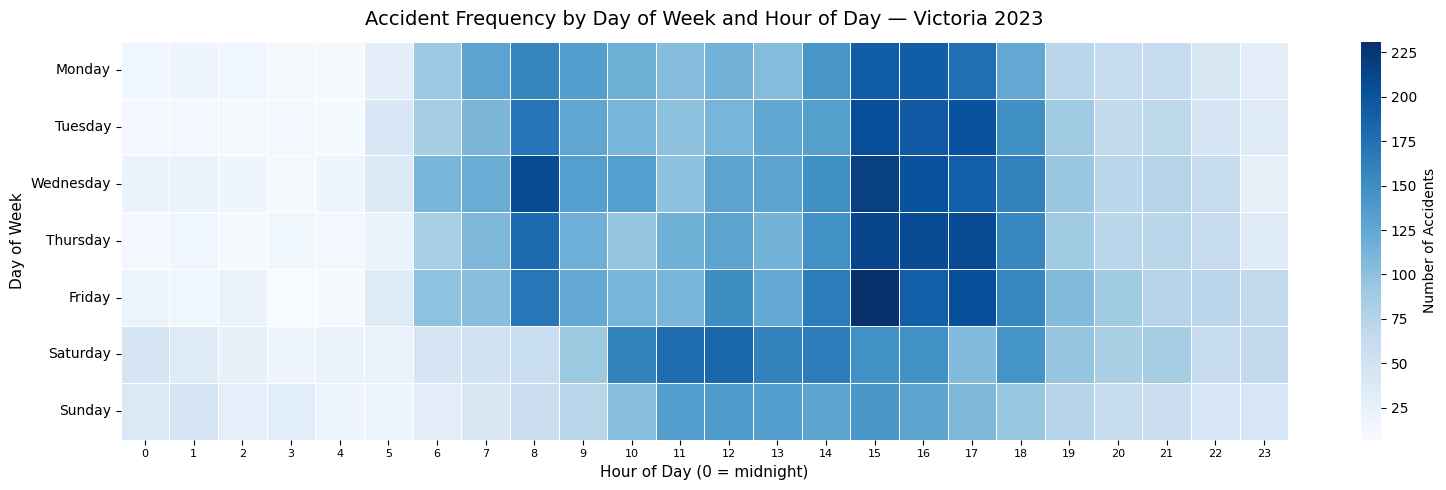

Insight: Weekdays show a clear morning peak (~8am) and stronger afternoon peak (3-5pm). Saturday evenings are elevated; Sunday mornings are the quietest period of the week.


In [17]:
# Chart 1: Heatmap — Day of Week x Hour of Day
# Best representation for a 7x24 frequency grid

# Extract hour from ACCIDENT_TIME for grouping (no new column stored)
df_hm = df_2023.copy()
df_hm['_hour'] = pd.to_numeric(
    df_hm['ACCIDENT_TIME'].astype(str).str.split(':').str[0].str.strip(),
    errors='coerce'
).astype('Int64')
df_hm = df_hm.dropna(subset=['_hour']).copy()
df_hm['_hour'] = df_hm['_hour'].astype(int)

pivot = (
    df_hm.groupby(['DAY_OF_WEEK', '_hour']).size()
    .unstack(fill_value=0)
    .reindex(DAY_ORDER)
)
# Cast to float64 — avoids numpy/seaborn dtype conflict in Jupyter
pivot_values = pivot.fillna(0).astype(np.float64)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot_values,
    cmap='Blues',
    linewidths=0.4,
    linecolor='white',
    annot=False,
    ax=ax,
    cbar_kws={'label': 'Number of Accidents'},
    xticklabels=pivot.columns.tolist(),
    yticklabels=DAY_ORDER
)
ax.set_title('Accident Frequency by Day of Week and Hour of Day — Victoria 2023', fontsize=14, pad=12)
ax.set_xlabel('Hour of Day (0 = midnight)', fontsize=11)
ax.set_ylabel('Day of Week', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

print('Insight: Weekdays show a clear morning peak (~8am) and stronger afternoon peak (3-5pm).',
      'Saturday evenings are elevated; Sunday mornings are the quietest period of the week.')

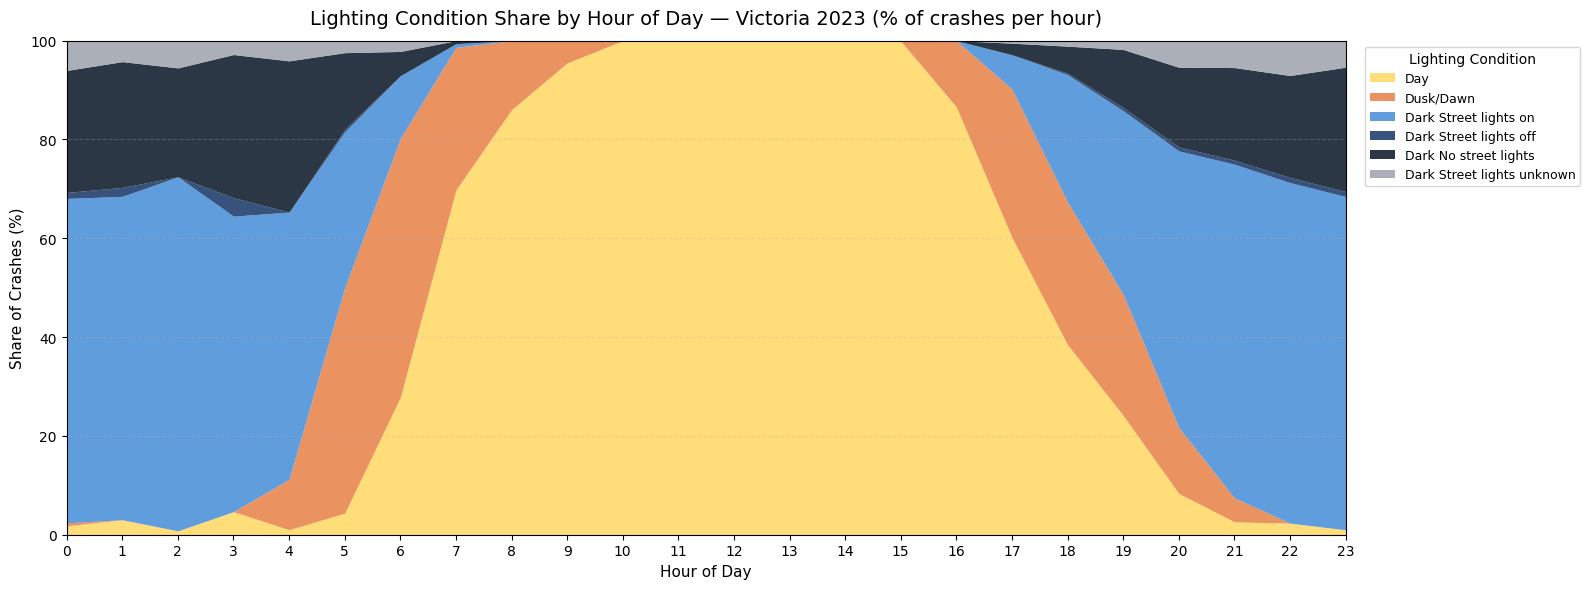

Insight: Before 6am and after 7pm dark conditions dominate entirely. The transition hours (6-8am and 5-7pm) show a clear handoff between Day and Dark street lights on. Dusk/Dawn sits as a narrow band at the margins of daylight hours.


In [18]:
# Chart 2: 100% stacked area chart — Lighting proportion by Hour of Day

df_lc = df_2023.copy()
df_lc['_hour'] = pd.to_numeric(
    df_lc['ACCIDENT_TIME'].astype(str).str.split(':').str[0].str.strip(),
    errors='coerce'
).astype('Int64')
df_lc = df_lc.dropna(subset=['_hour']).copy()
df_lc['_hour'] = df_lc['_hour'].astype(int)

lc_pivot = (
    df_lc.groupby(['_hour', 'LIGHT_CONDITION']).size()
    .unstack(fill_value=0)
    .reindex(columns=[c for c in LIGHT_ORDER if c in df_lc['LIGHT_CONDITION'].unique()])
)

# Normalise to 100% per hour
lc_pct = lc_pivot.div(lc_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 6))
lc_pct.plot(
    kind='area', stacked=True,
    color=[LIGHT_PALETTE[c] for c in lc_pct.columns],
    ax=ax, alpha=0.88, linewidth=0
)
ax.set_title('Lighting Condition Share by Hour of Day — Victoria 2023 (% of crashes per hour)',
             fontsize=14, pad=12)
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Share of Crashes (%)', fontsize=11)
ax.set_xlim(0, 23)
ax.set_ylim(0, 100)
ax.set_xticks(range(0, 24))
ax.legend(title='Lighting Condition', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print('Insight: Before 6am and after 7pm dark conditions dominate entirely.',
      'The transition hours (6-8am and 5-7pm) show a clear handoff between Day and Dark street lights on.',
      'Dusk/Dawn sits as a narrow band at the margins of daylight hours.')

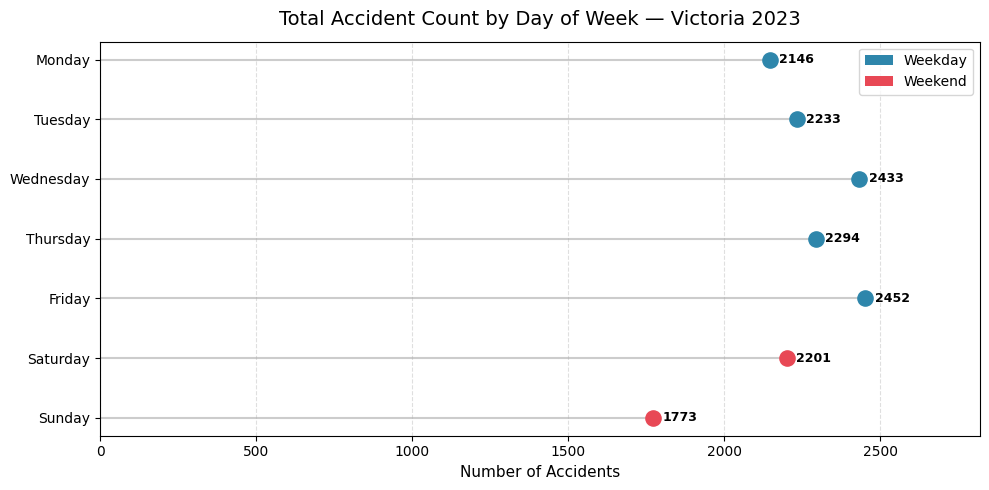

Insight: Friday and Wednesday record the highest weekday volumes. Sunday is the lowest overall. Saturday sits mid-range but carries a higher proportion of dark-condition crashes relative to its total volume.


In [19]:
# Chart 3: Lollipop chart — Total accidents by Day of Week
# Cleaner than a bar chart — same information with less visual weight

day_counts = df_2023['DAY_OF_WEEK'].value_counts().reindex(DAY_ORDER)
dot_colors = ['#2E86AB' if d not in ['Saturday', 'Sunday'] else '#E84855' for d in DAY_ORDER]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (day, count) in enumerate(zip(DAY_ORDER, day_counts.values)):
    ax.plot([0, count], [i, i], color='#CCCCCC', linewidth=1.5, zorder=1)
    ax.scatter(count, i, color=dot_colors[i], s=120, zorder=2)
    ax.text(count + 30, i, str(count), va='center', fontsize=9, fontweight='bold')

ax.set_yticks(range(len(DAY_ORDER)))
ax.set_yticklabels(DAY_ORDER, fontsize=10)
ax.set_xlabel('Number of Accidents', fontsize=11)
ax.set_title('Total Accident Count by Day of Week — Victoria 2023', fontsize=14, pad=12)
ax.set_xlim(0, day_counts.max() * 1.15)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.invert_yaxis()

legend_elems = [
    Patch(facecolor='#2E86AB', label='Weekday'),
    Patch(facecolor='#E84855', label='Weekend')
]
ax.legend(handles=legend_elems, fontsize=10)
plt.tight_layout()
plt.show()

print("Insight: Friday and Wednesday record the highest weekday volumes.",
      "Sunday is the lowest overall. Saturday sits mid-range but carries a higher",
      "proportion of dark-condition crashes relative to its total volume.")

## Task 2.2 — SPEED_ZONE vs INJ_OR_FATAL and Severity Distribution

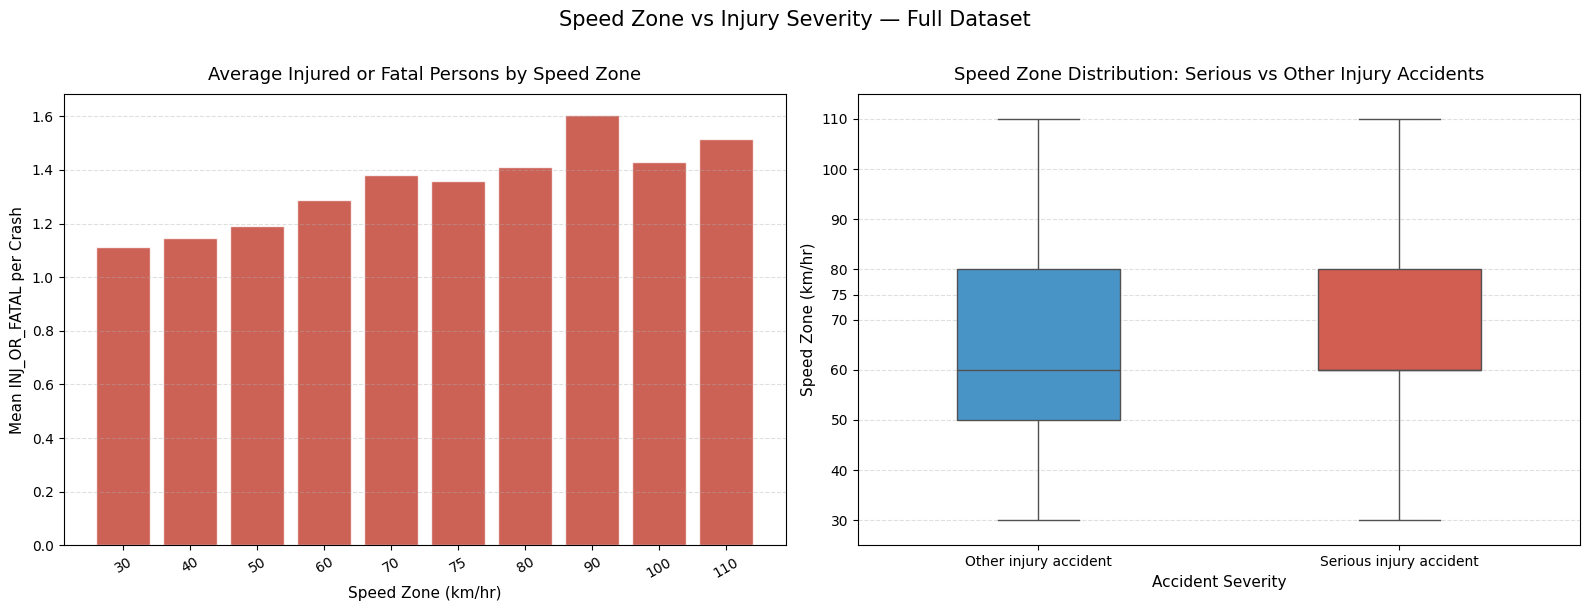

Insight: Higher speed zones correlate with higher average injury/fatality counts per crash.
Serious injury accidents cluster at higher speed zones than Other injury accidents,
confirming that kinetic energy at higher speeds directly amplifies crash severity.


In [20]:
df['SPEED_ZONE_NUM'] = df['SPEED_ZONE'].str.extract(r'^(\d+)').astype(float)

speed_inj = (
    df.dropna(subset=['SPEED_ZONE_NUM'])
    .groupby('SPEED_ZONE_NUM')['INJ_OR_FATAL'].mean()
    .reset_index().sort_values('SPEED_ZONE_NUM')
)
speed_inj.columns = ['Speed (km/hr)', 'Avg Inj or Fatal']

severity_filter = ['Serious injury accident', 'Other injury accident']
df_sev = df[df['SEVERITY'].isin(severity_filter)].dropna(subset=['SPEED_ZONE_NUM']).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(speed_inj['Speed (km/hr)'].astype(int).astype(str),
            speed_inj['Avg Inj or Fatal'],
            color='#c0392b', alpha=0.8, edgecolor='white')
axes[0].set_title('Average Injured or Fatal Persons by Speed Zone', fontsize=13, pad=10)
axes[0].set_xlabel('Speed Zone (km/hr)', fontsize=11)
axes[0].set_ylabel('Mean INJ_OR_FATAL per Crash', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_sev, x='SEVERITY', y='SPEED_ZONE_NUM', hue='SEVERITY',
            palette={'Serious injury accident': '#e74c3c', 'Other injury accident': '#3498db'},
            width=0.45, legend=False, ax=axes[1])
axes[1].set_yticks([30, 40, 50, 60, 70, 75, 80, 90, 100, 110])
axes[1].set_ylim(25, 115)
axes[1].set_title('Speed Zone Distribution: Serious vs Other Injury Accidents', fontsize=13, pad=10)
axes[1].set_xlabel('Accident Severity', fontsize=11)
axes[1].set_ylabel('Speed Zone (km/hr)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Speed Zone vs Injury Severity — Full Dataset', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print("Insight: Higher speed zones correlate with higher average injury/fatality counts per crash.")
print("Serious injury accidents cluster at higher speed zones than Other injury accidents,")
print("confirming that kinetic energy at higher speeds directly amplifies crash severity.")

## Task 2.3 — Crash Distribution by Geographic Area with Risk Factor Analysis

In [21]:
top_5_lgas = df['LGA_NAME'].value_counts().head(5).index.tolist()
df_top5    = df[df['LGA_NAME'].isin(top_5_lgas)].copy()

print("Top 5 LGAs by total crash count:")
print(df['LGA_NAME'].value_counts().head(5).to_string())

Top 5 LGAs by total crash count:
LGA_NAME
MELBOURNE    7648
CASEY        7127
GEELONG      6059
HUME         5651
DANDENONG    5183


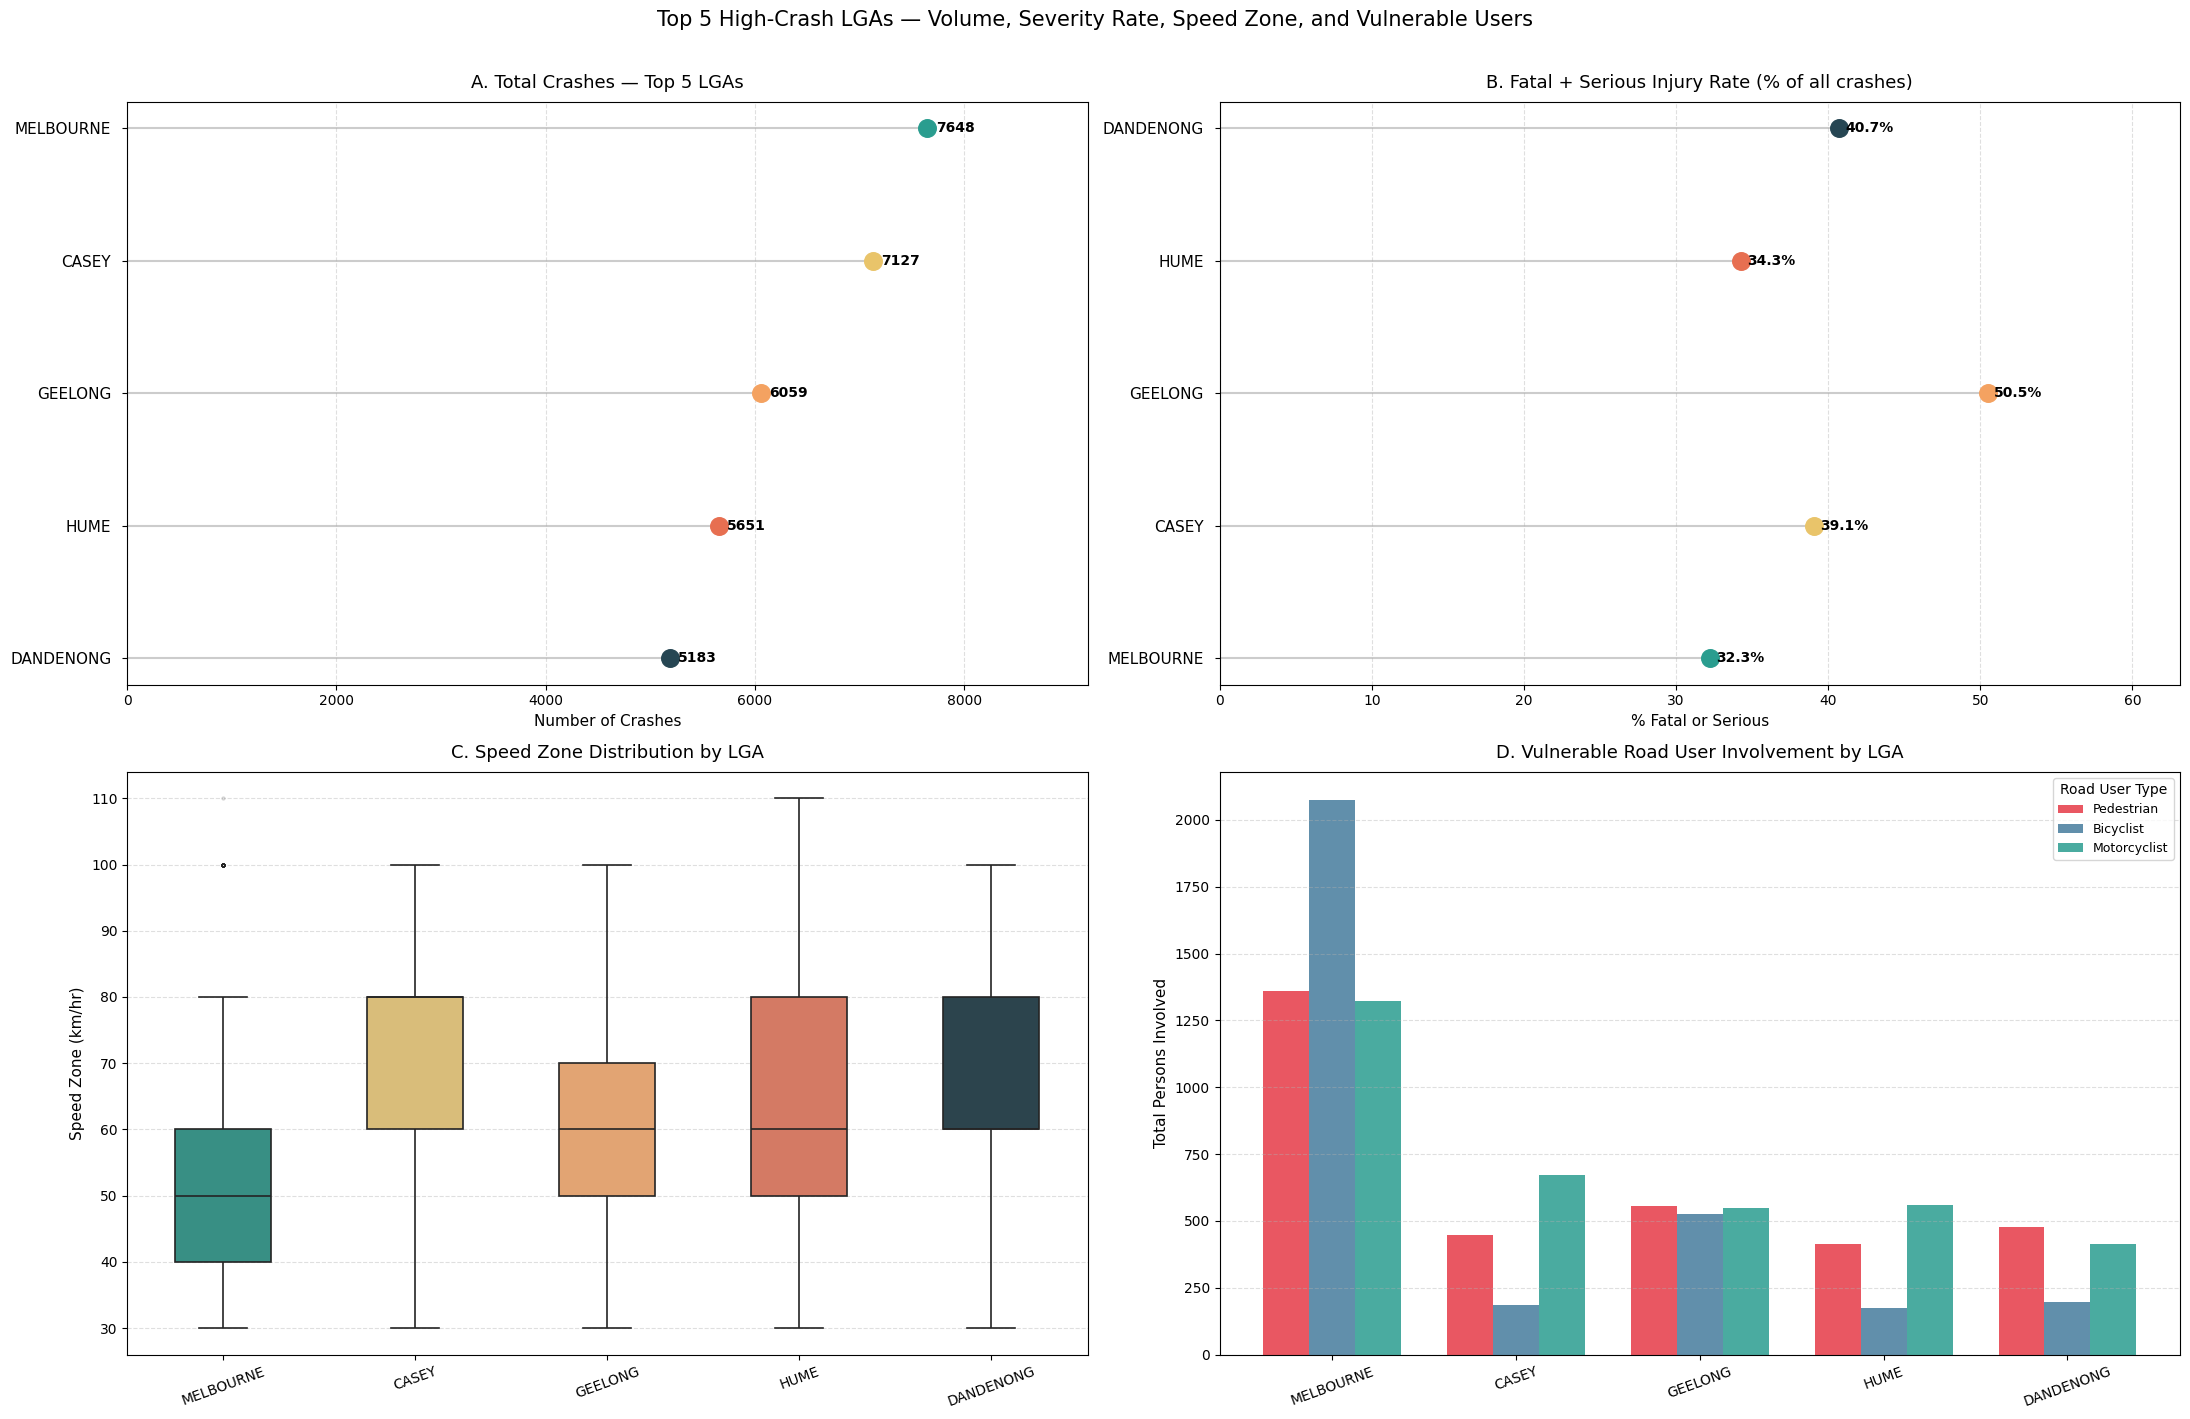

In [22]:
# Teal-to-coral diverging palette — distinct, readable, colourblind-friendly
LGA_COLORS   = ['#2A9D8F', '#E9C46A', '#F4A261', '#E76F51', '#264653']
lga_palette  = dict(zip(top_5_lgas, LGA_COLORS))
crash_counts = df_top5['LGA_NAME'].value_counts().reindex(top_5_lgas)

fig, axes = plt.subplots(2, 2, figsize=(22, 14))
plt.subplots_adjust(hspace=0.45, wspace=0.55)  # more horizontal space between cols

# A: Lollipop — total crashes
for i, (lga, count) in enumerate(zip(crash_counts.index[::-1], crash_counts.values[::-1])):
    axes[0,0].plot([0, count], [i, i], color='#CCCCCC', linewidth=1.5, zorder=1)
    axes[0,0].scatter(count, i, color=lga_palette[lga], s=160, zorder=2)
    axes[0,0].text(count + 80, i, str(count), va='center', fontsize=10, fontweight='bold')
axes[0,0].set_yticks(range(5))
axes[0,0].set_yticklabels(crash_counts.index[::-1], fontsize=11)
axes[0,0].set_title('A. Total Crashes — Top 5 LGAs', fontsize=13, pad=10)
axes[0,0].set_xlabel('Number of Crashes', fontsize=11)
axes[0,0].set_xlim(0, crash_counts.max() * 1.2)
axes[0,0].grid(axis='x', linestyle='--', alpha=0.4)
axes[0,0].tick_params(axis='y', labelsize=11)
# push y-axis labels away from spine so they don't get clipped
axes[0,0].yaxis.set_tick_params(pad=8)

# B: Dot plot — fatal + serious injury rate
severity_counts = (
    df_top5.groupby(['LGA_NAME','SEVERITY']).size().unstack(fill_value=0).reindex(top_5_lgas)
)
severity_counts['Rate'] = (
    (severity_counts.get('Fatal accident', 0) + severity_counts.get('Serious injury accident', 0))
    / crash_counts * 100
)
for i, (lga, row) in enumerate(severity_counts.iterrows()):
    axes[0,1].plot([0, row['Rate']], [i, i], color='#CCCCCC', linewidth=1.5, zorder=1)
    axes[0,1].scatter(row['Rate'], i, color=lga_palette[lga], s=160, zorder=2)
    axes[0,1].text(row['Rate'] + 0.4, i, f"{row['Rate']:.1f}%", va='center', fontsize=10, fontweight='bold')
axes[0,1].set_yticks(range(5))
axes[0,1].set_yticklabels(severity_counts.index, fontsize=11)
axes[0,1].set_title('B. Fatal + Serious Injury Rate (% of all crashes)', fontsize=13, pad=10)
axes[0,1].set_xlabel('% Fatal or Serious', fontsize=11)
axes[0,1].set_xlim(0, severity_counts['Rate'].max() * 1.25)
axes[0,1].grid(axis='x', linestyle='--', alpha=0.4)
axes[0,1].yaxis.set_tick_params(pad=8)

# C: Box plot — much more readable than strip for this many points
# Strip was collapsing 150k dots into unreadable blobs at discrete speed values
df_top5['SPEED_ZONE_NUM'] = df_top5['SPEED_ZONE'].str.extract(r'^(\d+)').astype(float)
sns.boxplot(
    data=df_top5.dropna(subset=['SPEED_ZONE_NUM']),
    x='LGA_NAME', y='SPEED_ZONE_NUM', order=top_5_lgas,
    palette=lga_palette, width=0.5, linewidth=1.2,
    flierprops=dict(marker='o', markersize=2, alpha=0.2),
    ax=axes[1,0]
)
axes[1,0].set_title('C. Speed Zone Distribution by LGA', fontsize=13, pad=10)
axes[1,0].set_ylabel('Speed Zone (km/hr)', fontsize=11)
axes[1,0].set_xlabel('')
axes[1,0].set_yticks([30, 40, 50, 60, 70, 80, 90, 100, 110])
axes[1,0].tick_params(axis='x', rotation=20, labelsize=10)
axes[1,0].grid(axis='y', linestyle='--', alpha=0.4)

# D: Grouped bar — vulnerable users
vuln  = df_top5.groupby('LGA_NAME')[['PEDESTRIAN','BICYCLIST','MOTORCYCLIST']].sum().reindex(top_5_lgas)
x     = np.arange(len(top_5_lgas))
width = 0.25
axes[1,1].bar(x - width, vuln['PEDESTRIAN'],   width, label='Pedestrian',   color='#E63946', alpha=0.85)
axes[1,1].bar(x,          vuln['BICYCLIST'],    width, label='Bicyclist',    color='#457B9D', alpha=0.85)
axes[1,1].bar(x + width,  vuln['MOTORCYCLIST'], width, label='Motorcyclist', color='#2A9D8F', alpha=0.85)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(top_5_lgas, rotation=20, fontsize=10)
axes[1,1].set_title('D. Vulnerable Road User Involvement by LGA', fontsize=13, pad=10)
axes[1,1].set_ylabel('Total Persons Involved', fontsize=11)
axes[1,1].legend(title='Road User Type', fontsize=9)
axes[1,1].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle(
    'Top 5 High-Crash LGAs — Volume, Severity Rate, Speed Zone, and Vulnerable Users',
    fontsize=15, y=1.01
)
plt.tight_layout()
plt.show()

In [23]:
print("""
Interpretation:

Plot A shows raw crash volume — dense urban LGAs like Melbourne and Casey generate the highest
counts driven by traffic density, not necessarily inherent road danger.

Plot B (fatal + serious rate) reframes this. An LGA with fewer total crashes can still carry
a disproportionately high serious-injury rate if it has more high-speed roads.
Plot C provides context — the strip plot shows where crashes cluster by speed zone, and LGAs
with higher medians (black line) tend to show elevated serious-injury rates.

Plot D (grouped bars) makes it easy to compare user types side by side per LGA. Inner-urban
LGAs produce more pedestrian and cyclist casualties reflecting denser foot traffic and shared
road use. Motorcyclist involvement is more evenly spread across all five LGAs.

Key story: high-volume urban LGAs are dominated by lower-speed collisions with higher
pedestrian/cyclist exposure, while LGAs with higher speed-zone medians carry a
disproportionate share of fatal and serious injury outcomes per crash.
""")


Interpretation:

Plot A shows raw crash volume — dense urban LGAs like Melbourne and Casey generate the highest
counts driven by traffic density, not necessarily inherent road danger.

Plot B (fatal + serious rate) reframes this. An LGA with fewer total crashes can still carry
a disproportionately high serious-injury rate if it has more high-speed roads.
Plot C provides context — the strip plot shows where crashes cluster by speed zone, and LGAs
with higher medians (black line) tend to show elevated serious-injury rates.

Plot D (grouped bars) makes it easy to compare user types side by side per LGA. Inner-urban
LGAs produce more pedestrian and cyclist casualties reflecting denser foot traffic and shared
road use. Motorcyclist involvement is more evenly spread across all five LGAs.

Key story: high-volume urban LGAs are dominated by lower-speed collisions with higher
pedestrian/cyclist exposure, while LGAs with higher speed-zone medians carry a
disproportionate share of fatal and seri